In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [4]:
compas = pd.read_csv('compas-scores-raw.csv')

# False Positives and False Negatives 

In [6]:
fl_df = pd.read_csv("cox-violent-parsed.csv")
fl2_df = pd.read_csv("compas-scores-raw.csv")

fl_df['full_name'] = fl_df['first'].str.lower().str.strip() + ' ' + fl_df['last'].str.lower().str.strip()
fl2_df['full_name'] = fl2_df['FirstName'].str.lower().str.strip() + ' ' + fl2_df['LastName'].str.lower().str.strip()

merged_df = pd.merge(fl_df, fl2_df, on='full_name', how='inner', suffixes=('_fl', '_ny'))

In [8]:
#Defining categories of risk based on score number 
merged_df['score_group'] = merged_df['decile_score'].apply(
    lambda x: 'High' if x >= 8 else 'Medium' if x >= 5 else 'Low'
)

In [10]:
#Creating error labels (low score + did reoffended vs high score + didnt reoffend) 
merged_df['false_positive'] = (merged_df['score_group'] == 'High') & (merged_df['is_recid'] == 0)
merged_df['false_negative'] = (merged_df['score_group'] == 'Low') & (merged_df['is_recid'] == 1)

In [12]:
#Function is meant to define false positive and false negative rates
def fp_fn_rates_by(feature):
    grouped = merged_df.groupby(feature)
    fp_rate = grouped['false_positive'].sum() / (grouped.apply(lambda g: (g['score_group'] == 'High').sum()) + 1e-6)
    fn_rate = grouped['false_negative'].sum() / (grouped.apply(lambda g: (g['score_group'] == 'Low').sum()) + 1e-6)
    return fp_rate.sort_values(ascending=False), fn_rate.sort_values(ascending=False)

In [14]:
#Testing for legal status and marital status 
fp_by_legal, fn_by_legal = fp_fn_rates_by('LegalStatus')
fp_by_marital, fn_by_marital = fp_fn_rates_by('MaritalStatus')

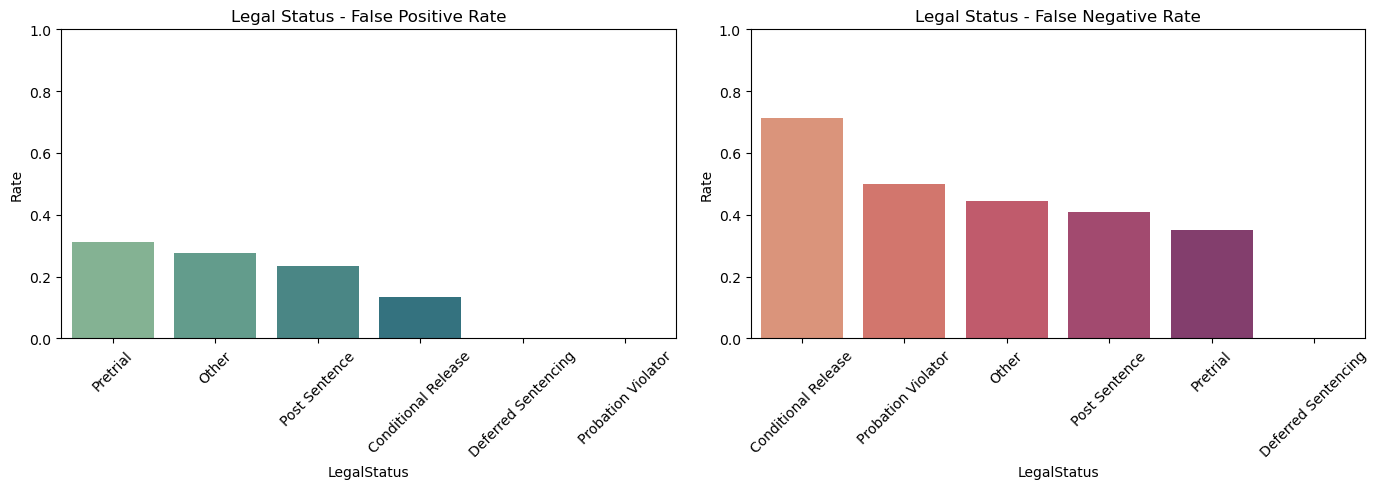

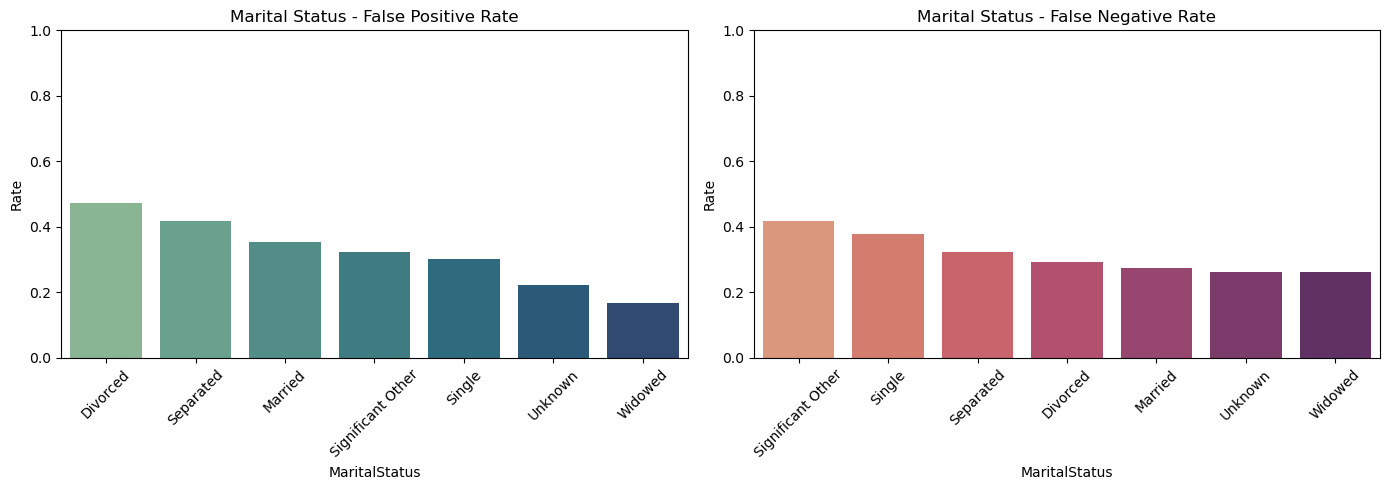

In [16]:
def plot_fp_fn(fp_series, fn_series, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(x=fp_series.index, y=fp_series.values, ax=axes[0], palette='crest')
    axes[0].set_title(f'{title_prefix} - False Positive Rate')
    axes[0].set_ylabel('Rate')
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(x=fn_series.index, y=fn_series.values, ax=axes[1], palette='flare')
    axes[1].set_title(f'{title_prefix} - False Negative Rate')
    axes[1].set_ylabel('Rate')
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot for Legal and Marital Status
plot_fp_fn(fp_by_legal, fn_by_legal, "Legal Status")
plot_fp_fn(fp_by_marital, fn_by_marital, "Marital Status")

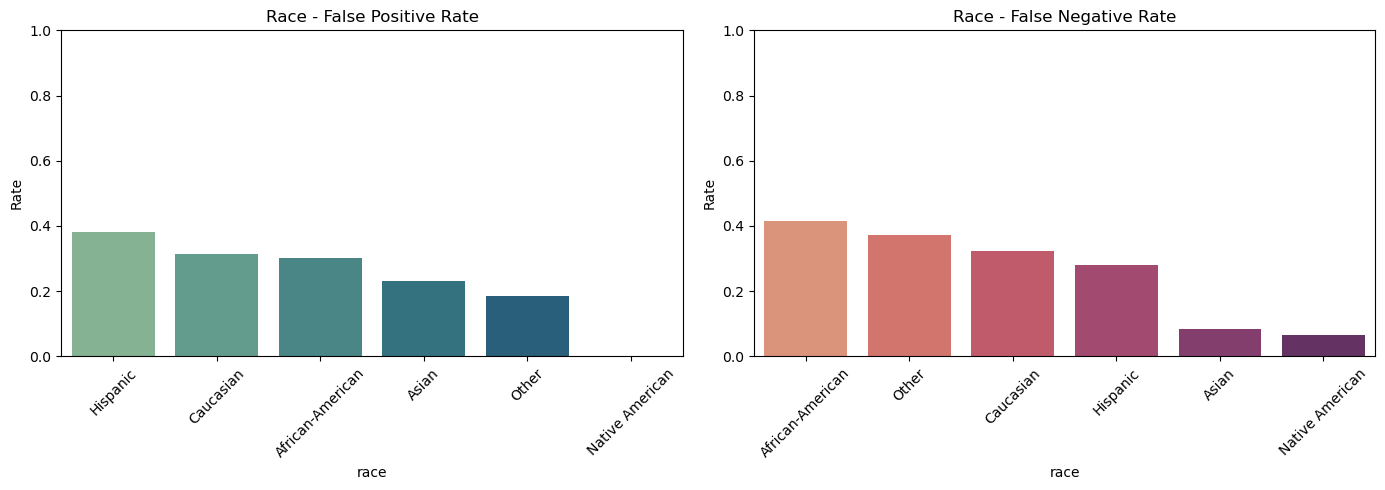

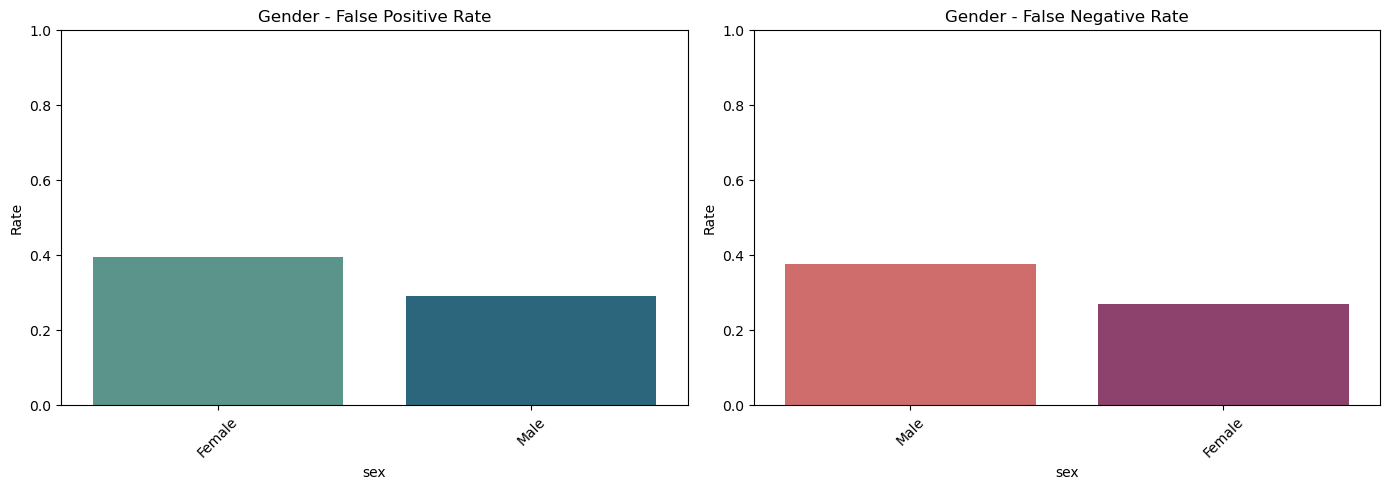

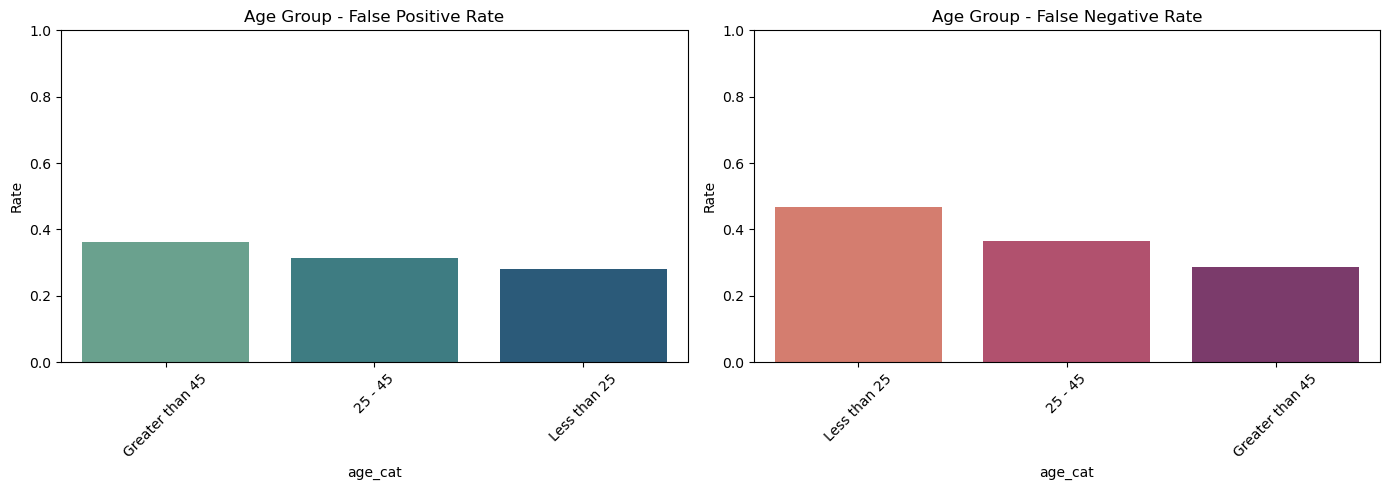

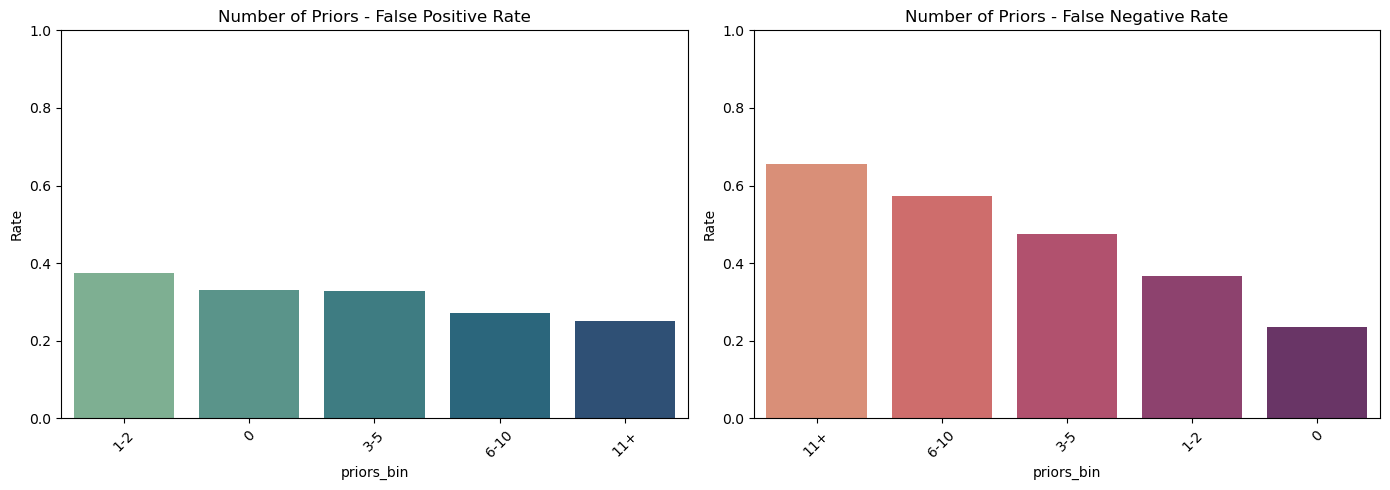

In [18]:
def priors_bin(n):
    if n == 0:
        return "0"
    elif n <= 2:
        return "1-2"
    elif n <= 5:
        return "3-5"
    elif n <= 10:
        return "6-10"
    else:
        return "11+"

merged_df['priors_bin'] = merged_df['priors_count'].apply(priors_bin)

fp_by_race, fn_by_race = fp_fn_rates_by('race')
fp_by_sex, fn_by_sex = fp_fn_rates_by('sex')
fp_by_age, fn_by_age = fp_fn_rates_by('age_cat')
fp_by_priors, fn_by_priors = fp_fn_rates_by('priors_bin')

plot_fp_fn(fp_by_race, fn_by_race, "Race")
plot_fp_fn(fp_by_sex, fn_by_sex, "Gender")
plot_fp_fn(fp_by_age, fn_by_age, "Age Group")
plot_fp_fn(fp_by_priors, fn_by_priors, "Number of Priors")

In [20]:
#Looking at how accurate the model even is for all people 
def group_reoffend_stats(df, group_col='score_group'):
    grouped = df.groupby(group_col)
    total = grouped.size()
    recid = grouped['is_recid'].sum()
    recid_rate = recid / total
    return pd.DataFrame({
        'Total Individuals': total,
        'Reoffended': recid,
        'Recidivism Rate': recid_rate
    }).sort_index()

score_group_summary = group_reoffend_stats(merged_df)
score_group_summary

,Total Individuals,Reoffended,Recidivism Rate
score_group,,,
High,17895,11172,0.624308
Low,29553,8829,0.298751
Medium,18390,9774,0.531485


# Beginning Fairness part 

Our analysis shows that COMPAS does not satisfy Equalized Odds when comparing Black and White defendants. Black individuals experience both a higher true positive rate and a higher false positive rate, meaning they are more likely to be correctly flagged and wrongly flagged as high risk. This aligns with ProPublica’s 2016 findings and constitutes a textbook example of disparate impact as discussed in class.

Equalized Odds is one of the stricter group fairness metrics because it requires equal error rates across protected attributes. COMPAS’s failure to meet this bar reveals potential algorithmic discrimination, where the system disproportionately harms one group due to patterns embedded in its structure or training data. This supports broader concerns raised in both the lecture and ProPublica reading: proprietary algorithms in criminal justice settings can amplify historical bias, lack transparency, and challenge due process. 

In [22]:
def equalized_odds_by(feature):
    df = merged_df.copy()
    df = df[df[feature].notna()]
    df['tp'] = (df['score_group'] == 'High') & (df['is_recid'] == 1)
    df['fp'] = (df['score_group'] == 'High') & (df['is_recid'] == 0)
    df['tn'] = (df['score_group'] != 'High') & (df['is_recid'] == 0)
    df['fn'] = (df['score_group'] != 'High') & (df['is_recid'] == 1)
    confusion = df.groupby(feature).agg({'tp': 'sum', 'fp': 'sum', 'tn': 'sum', 'fn': 'sum'})
    confusion['TPR'] = confusion['tp'] / (confusion['tp'] + confusion['fn'])
    confusion['FPR'] = confusion['fp'] / (confusion['fp'] + confusion['tn'])
    return confusion[['TPR', 'FPR']]

# For gender and age group
equalized_odds_by('sex'), equalized_odds_by('age_cat')

(             TPR       FPR
 sex                       
 Female  0.292784  0.144286
 Male    0.370496  0.191808,
                       TPR       FPR
 age_cat                            
 25 - 45          0.355285  0.182332
 Greater than 45  0.204532  0.080948
 Less than 25     0.450718  0.308450)

## Equalized Odds Fairness Analysis

### Group-wise TPR and FPR

| Group Type | Group              | TPR (True Positive Rate) | FPR (False Positive Rate) |
|------------|--------------------|---------------------------|----------------------------|
| **Race**   | African-American   | 43.4%                    | 27.7%                      |
|            | Caucasian          | 24.8%                    | 10.1%                      |
| **Gender** | Male               | 37.0%                    | 19.2%                      |
|            | Female             | 29.3%                    | 14.4%                      |
| **Age**    | < 25               | 45.1%                    | 30.8%                      |
|            | 25–45              | 35.5%                    | 18.2%                      |
|            | > 45               | 20.5%                    | 8.1%                       |

## Equal Opportunity Fairness Analysis


### TPR by Group (Among True Recidivists Only)

| Group Type | Group              | TPR (True Positive Rate) |
|------------|--------------------|---------------------------|
| **Race**   | Native American    | 67.6% 
|            | Asian              | 50.0%  
|            | African-American   | 43.4%  
|            | Caucasian          | 24.8%  
|            | Hispanic           | 22.9%  
|            | Other              | 14.9%   
| **Gender** | Male               | 37.0%  
|            | Female             | 29.3%  
| **Age**    | Less than 25       | 45.1%   
|            | 25 – 45            | 35.5%  
|            | Greater than 45    | 20.5%  

## Demographic Parity Fairness Analysis


### % of People Labeled "High Risk" (Predicted Positive)

| Group Type | Group              | % Labeled High Risk |
|------------|--------------------|----------------------|
| **Race**   | African-American   | 36.7%  
|            | Native American    | 31.9%  
|            | Asian              | 17.8%  
|            | Caucasian          | 16.5%  
|            | Hispanic           | 14.7%  
|            | Other              | 7.8%  
| **Gender** | Male               | 28.5%  
|            | Female             | 20.5% 
| **Age**    | Less than 25       | 39.9% 
|            | 25–45              | 26.8%  
|            | Greater than 45    | 12.6% 

## Comparative Fairness Summary: COMPAS Risk Assessment


### Summary Table

| Fairness Metric      | What It Measures                                             | COMPAS Satisfies It? | Key Violations                         |
|----------------------|--------------------------------------------------------------|-----------------------|----------------------------------------|
| **Equalized Odds**   | Equal **TPR** and **FPR** across groups                      | No                 | Race, Age, Gender                      |
| **Equal Opportunity**| Equal **TPR** across groups (ignores FPR)                   | No                 | Race, Age, Gender                      |
| **Demographic Parity**| Equal % labeled high risk across groups (ignores outcome)  | No                 | Race, Age, Gender                      |

## Visualizations

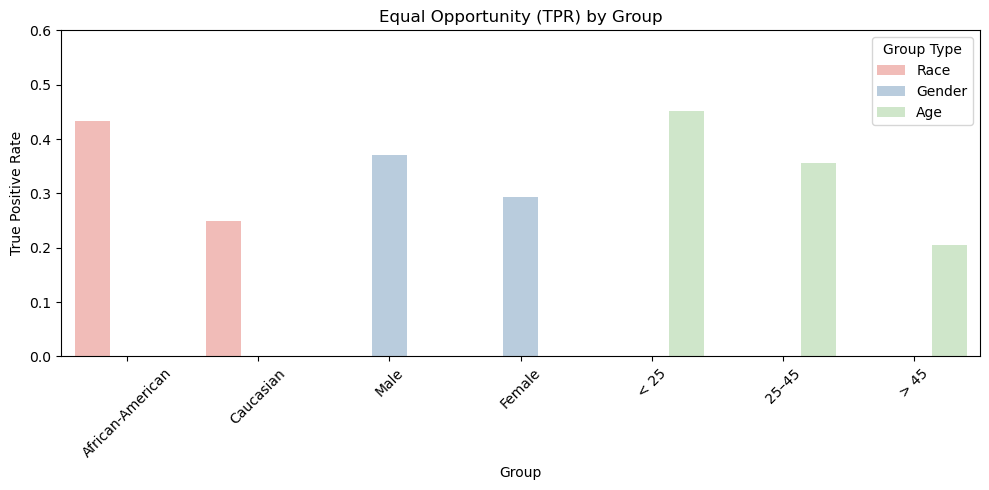

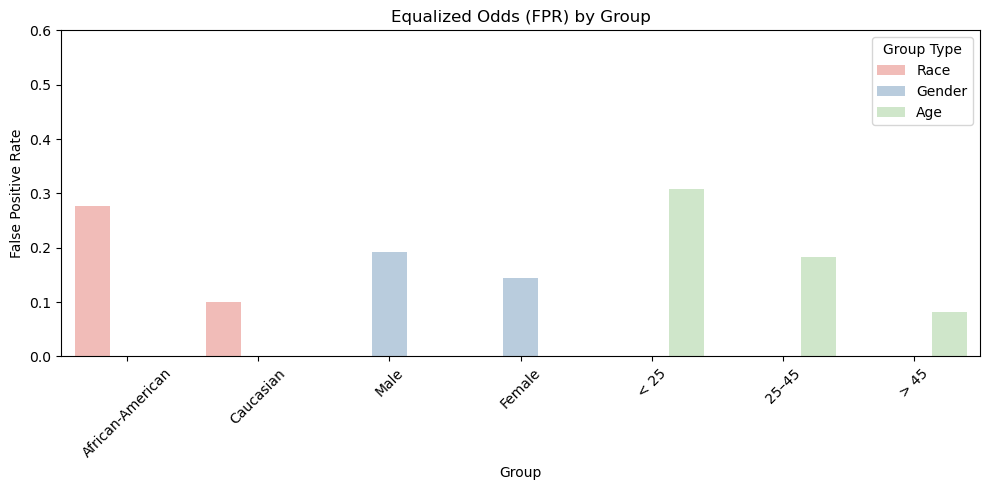

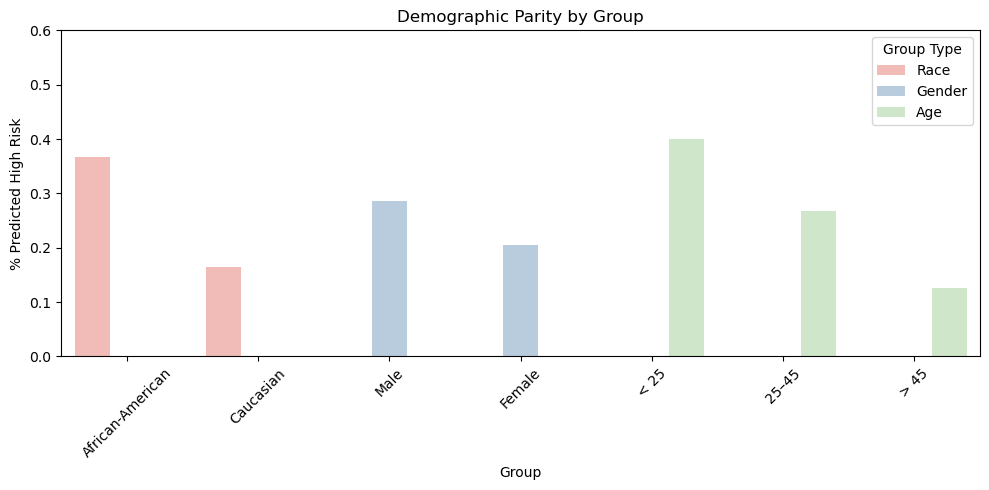

In [34]:
# === FAIRNESS METRIC DATA ===
fairness_summary = pd.DataFrame({
    'Group': ['African-American', 'Caucasian', 'Male', 'Female', '< 25', '25–45', '> 45'],
    'Group Type': ['Race', 'Race', 'Gender', 'Gender', 'Age', 'Age', 'Age'],
    'TPR (Equal Opportunity)': [0.4337, 0.2484, 0.3705, 0.2928, 0.4507, 0.3553, 0.2045],
    'FPR (Equalized Odds)': [0.2768, 0.1009, 0.1918, 0.1443, 0.3085, 0.1823, 0.0809],
    '% Labeled High Risk (Demographic Parity)': [0.3672, 0.1647, 0.2854, 0.2054, 0.3993, 0.2680, 0.1258]
})

# === VISUALIZATION 1: Equal Opportunity ===
plt.figure(figsize=(10, 5))
sns.barplot(data=fairness_summary,
            x='Group',
            y='TPR (Equal Opportunity)',
            hue='Group Type',
            palette='Pastel1')
plt.title('Equal Opportunity (TPR) by Group')
plt.ylabel('True Positive Rate')
plt.ylim(0, 0.6)
plt.xticks(rotation=45)
plt.legend(title='Group Type')
plt.tight_layout()
plt.savefig("equal opportunity")
plt.show()

# === VISUALIZATION 2: Equalized Odds ===
plt.figure(figsize=(10, 5))
sns.barplot(data=fairness_summary,
            x='Group',
            y='FPR (Equalized Odds)',
            hue='Group Type',
            palette='Pastel1')
plt.title('Equalized Odds (FPR) by Group')
plt.ylabel('False Positive Rate')
plt.ylim(0, 0.6)
plt.xticks(rotation=45)
plt.legend(title='Group Type')
plt.tight_layout()
plt.savefig("equalized odds")
plt.show()

# === VISUALIZATION 3: Demographic Parity ===
plt.figure(figsize=(10, 5))
sns.barplot(data=fairness_summary,
            x='Group',
            y='% Labeled High Risk (Demographic Parity)',
            hue='Group Type',
            palette='Pastel1')
plt.title('Demographic Parity by Group')
plt.ylabel('% Predicted High Risk')
plt.ylim(0, 0.6)
plt.xticks(rotation=45)
plt.legend(title='Group Type')
plt.tight_layout()
plt.savefig("demographic parity")
plt.show()